<a href="https://colab.research.google.com/github/Lixiaobo6/ML2026_autumn/blob/main/D2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Импорт библиотек
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)

Выборочная ковариационная матрица:
 [[ 0.23312293 -0.23625764]
 [-0.23625764  0.46568054]]
Теоретическая ковариационная матрица:
 [[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]


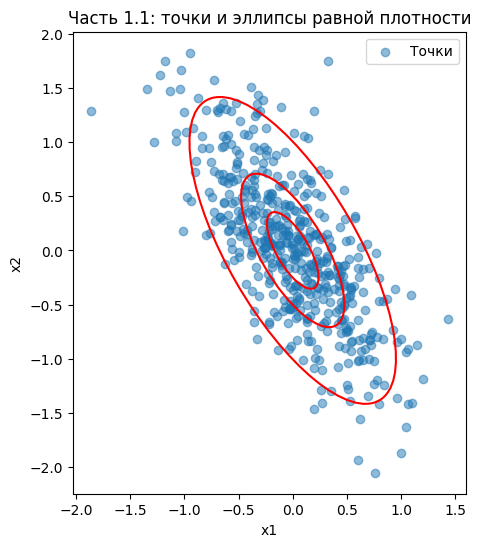

In [2]:
# Часть 1.1: Генерация данных с заданной ковариацией
M = 500
sigma1, sigma2 = 0.3, 0.8
alpha = np.deg2rad(30)

# Генерируем независимые признаки
x1 = np.random.normal(0, sigma1, M)
x2 = np.random.normal(0, sigma2, M)
X = np.column_stack([x1, x2])

# Матрица поворота
R = np.array([
    [np.cos(alpha), -np.sin(alpha)],
    [np.sin(alpha),  np.cos(alpha)]
])

# Поворачиваем точки
X_rot = X @ R.T

# Выборочная и теоретическая ковариация
C_sample = np.cov(X_rot.T)
C_theor = R @ np.diag([sigma1**2, sigma2**2]) @ R.T

print("Выборочная ковариационная матрица:\n", C_sample)
print("Теоретическая ковариационная матрица:\n", C_theor)

# Автопроверка
assert X_rot.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X_rot.T)[0, 1]) > 0.1, "Корреляция слишком мала"
assert np.allclose(np.mean(X_rot, axis=0), 0, atol=0.1), "Среднее должно быть около 0"

# Визуализация
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_rot[:, 0], X_rot[:, 1], alpha=0.5, label='Точки')

# Эллипсы равной плотности
vals, vecs = np.linalg.eigh(C_theor)
order = vals.argsort()[::-1]
vals, vecs = vals[order], vecs[:, order]
theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

for k in [0.5, 1, 2]:
    width = 2 * k * np.sqrt(vals[0])
    height = 2 * k * np.sqrt(vals[1])
    ell = Ellipse(
        (0, 0), width=width, height=height, angle=theta,
        fill=False, color='red', linewidth=1.5
    )
    ax.add_patch(ell)

ax.set_aspect('equal')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Часть 1.1: точки и эллипсы равной плотности')
ax.legend()
plt.show()

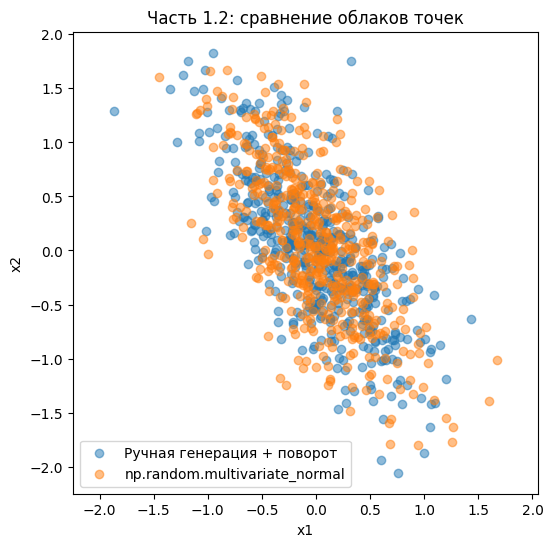

In [3]:
# Часть 1.2: Сравнение с np.random.multivariate_normal
X_mvn = np.random.multivariate_normal(mean=[0, 0], cov=C_theor, size=M)

plt.figure(figsize=(6, 6))
plt.scatter(X_rot[:, 0], X_rot[:, 1], alpha=0.5, label='Ручная генерация + поворот')
plt.scatter(X_mvn[:, 0], X_mvn[:, 1], alpha=0.5, label='np.random.multivariate_normal')
plt.axis('equal')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Часть 1.2: сравнение облаков точек')
plt.legend()
plt.show()

Максимальная разница: 3.3306690738754696e-16


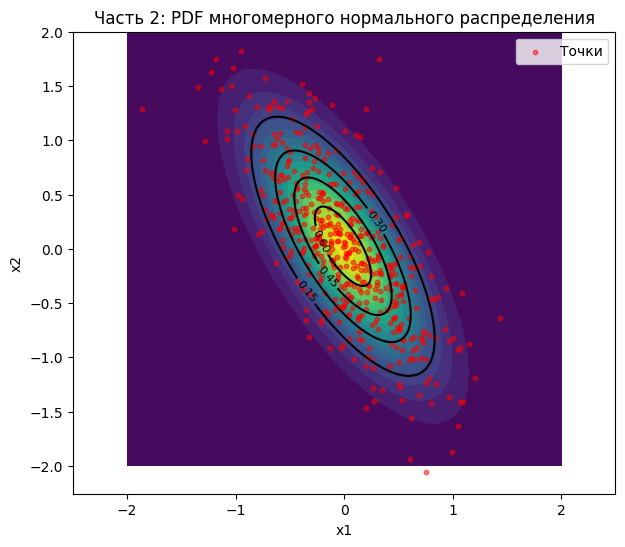

In [4]:
# Часть 2: оценка PDF и визуализация
mu_hat = np.mean(X_rot, axis=0)
C_hat = np.cov(X_rot.T)

# Сетка точек
xx, yy = np.meshgrid(
    np.linspace(-2, 2, 200),
    np.linspace(-2, 2, 200)
)
grid = np.dstack([xx, yy])

# PDF через scipy
mvn = multivariate_normal(mean=mu_hat, cov=C_hat)
pdf_scipy = mvn.pdf(grid)

# Ручное вычисление PDF
invC = np.linalg.inv(C_hat)
detC = np.linalg.det(C_hat)
diff = grid - mu_hat
mahal = np.einsum('...i,ij,...j->...', diff, invC, diff)
pdf_manual = 1 / (2 * np.pi * np.sqrt(detC)) * np.exp(-0.5 * mahal)

print("Максимальная разница:", np.max(np.abs(pdf_manual - pdf_scipy)))
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"

# Визуализация
plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, pdf_manual, levels=20, cmap='viridis')
cs = plt.contour(xx, yy, pdf_manual, levels=5, colors='black')
plt.clabel(cs, inline=True, fontsize=8)
plt.scatter(X_rot[:, 0], X_rot[:, 1], c='red', s=10, alpha=0.5, label='Точки')
plt.axis('equal')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Часть 2: PDF многомерного нормального распределения')
plt.legend()
plt.show()

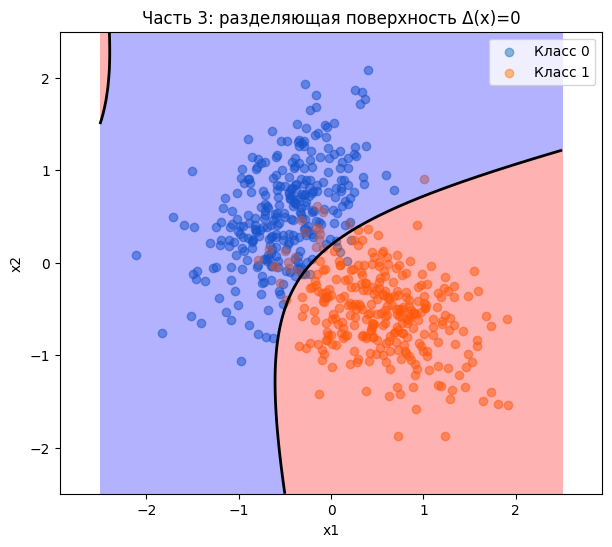

In [5]:
# Часть 3: бинарная классификация через байесовский подход
mu0 = np.array([-0.5, 0.5])
C0 = np.array([[0.2, 0.1],
               [0.1, 0.3]])

mu1 = np.array([0.5, -0.5])
C1 = np.array([[0.3, -0.1],
               [-0.1, 0.2]])

X0 = np.random.multivariate_normal(mu0, C0, 300)
X1 = np.random.multivariate_normal(mu1, C1, 300)

X3 = np.vstack([X0, X1])
y3 = np.hstack([np.zeros(300), np.ones(300)])

p0 = np.mean(y3 == 0)
p1 = np.mean(y3 == 1)

# Сетка
xx, yy = np.meshgrid(
    np.linspace(-2.5, 2.5, 300),
    np.linspace(-2.5, 2.5, 300)
)
grid = np.dstack([xx, yy])

pdf0 = multivariate_normal(mu0, C0).pdf(grid)
pdf1 = multivariate_normal(mu1, C1).pdf(grid)

delta = pdf0 * p0 - pdf1 * p1

plt.figure(figsize=(7, 6))
plt.scatter(X0[:, 0], X0[:, 1], alpha=0.5, label='Класс 0')
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.5, label='Класс 1')
plt.contourf(xx, yy, delta, levels=[delta.min(), 0, delta.max()],
             colors=['red', 'blue'], alpha=0.3)
plt.contour(xx, yy, delta, levels=[0], colors='black', linewidths=2)
plt.axis('equal')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Часть 3: разделяющая поверхность Δ(x)=0')
plt.legend()
plt.show()

In [6]:
# Часть 4.2: реализация MyLDA
class MyLDA(BaseEstimator, ClassifierMixin):
    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.priors_ = None
        self.cov_ = None
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_features = X.shape[1]
        n_total = len(y)

        self.means_ = {}
        self.priors_ = {}
        cov_sum = np.zeros((n_features, n_features))

        # Оценка средних, приоров и общей ковариации
        for c in self.classes_:
            Xc = X[y == c]
            self.means_[c] = np.mean(Xc, axis=0)
            self.priors_[c] = len(Xc) / n_total
            if len(Xc) > 1:
                cov_sum += (len(Xc) - 1) * np.cov(Xc.T, ddof=1)

        self.cov_ = cov_sum / (n_total - len(self.classes_))
        self.cov_ += 1e-6 * np.eye(n_features)

        # Бинарный случай: вычисляем w и b
        if len(self.classes_) == 2:
            c0, c1 = self.classes_[0], self.classes_[1]
            mu0, mu1 = self.means_[c0], self.means_[c1]
            invC = np.linalg.inv(self.cov_)

            w = invC @ (mu1 - mu0)
            b = (
                -0.5 * mu1 @ invC @ mu1
                + 0.5 * mu0 @ invC @ mu0
                + np.log(self.priors_[c1] / self.priors_[c0])
            )

            self.coef_ = w
            self.intercept_ = b

        return self

    def decision_function(self, X):
        X = np.asarray(X)

        if self.coef_ is not None:
            return X @ self.coef_ + self.intercept_

        # Многоклассовый случай
        invC = np.linalg.inv(self.cov_)
        scores = []
        for c in self.classes_:
            mu = self.means_[c]
            score = X @ invC @ mu - 0.5 * mu @ invC @ mu + np.log(self.priors_[c])
            scores.append(score)
        return np.column_stack(scores)

    def predict(self, X):
        if self.coef_ is not None:
            d = self.decision_function(X)
            return np.where(d > 0, self.classes_[1], self.classes_[0])

        scores = self.decision_function(X)
        return self.classes_[np.argmax(scores, axis=1)]

    def predict_proba(self, X):
        if self.coef_ is not None:
            d = self.decision_function(X)
            p1 = 1 / (1 + np.exp(-d))
            return np.column_stack([1 - p1, p1])

        scores = self.decision_function(X)
        scores -= np.max(scores, axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

MyLDA accuracy: 0.9277777777777778
sklearn LDA accuracy: 0.9277777777777778
Совпадение предсказаний: True


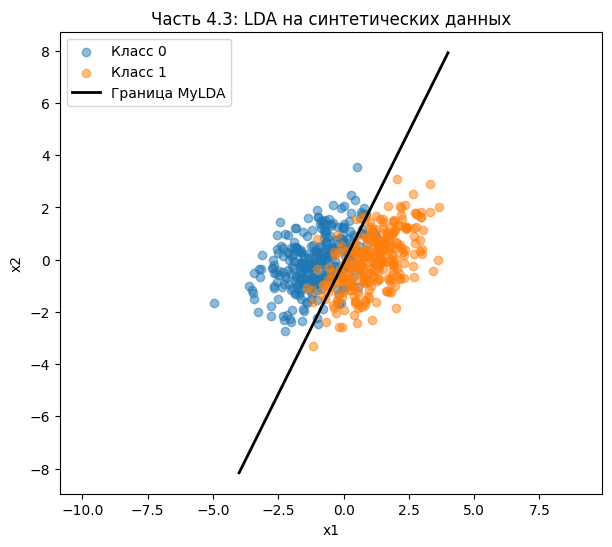

In [7]:
# Часть 4.3: проверка MyLDA на синтетике
C = np.array([[1.0, 0.5],
              [0.5, 1.0]])

mu0 = np.array([-1.0, 0.0])
mu1 = np.array([ 1.0, 0.0])

X0 = np.random.multivariate_normal(mu0, C, 300)
X1 = np.random.multivariate_normal(mu1, C, 300)

X4 = np.vstack([X0, X1])
y4 = np.hstack([np.zeros(300), np.ones(300)])

X_train, X_test, y_train, y_test = train_test_split(
    X4, y4, test_size=0.3, random_state=0, stratify=y4
)

my_lda = MyLDA().fit(X_train, y_train)
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)

pred_my = my_lda.predict(X_test)
pred_sk = sk_lda.predict(X_test)

print("MyLDA accuracy:", accuracy_score(y_test, pred_my))
print("sklearn LDA accuracy:", accuracy_score(y_test, pred_sk))
print("Совпадение предсказаний:", np.array_equal(pred_my, pred_sk))

# Визуализация разделяющей прямой
plt.figure(figsize=(7, 6))
plt.scatter(X0[:, 0], X0[:, 1], alpha=0.5, label='Класс 0')
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.5, label='Класс 1')

xx = np.linspace(-4, 4, 100)
w = my_lda.coef_
b = my_lda.intercept_
yy = -(w[0] * xx + b) / w[1]

plt.plot(xx, yy, 'k-', linewidth=2, label='Граница MyLDA')
plt.axis('equal')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Часть 4.3: LDA на синтетических данных')
plt.legend()
plt.show()

In [8]:
# Часть 5.2: реализация MyNB
class MyNB(BaseEstimator, ClassifierMixin):
    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.vars_ = None
        self.priors_ = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}
        n_total = len(y)

        # Для каждого класса оцениваем среднее, дисперсию и приор
        for c in self.classes_:
            Xc = X[y == c]
            self.means_[c] = np.mean(Xc, axis=0)
            self.vars_[c] = np.var(Xc, axis=0) + 1e-9
            self.priors_[c] = len(Xc) / n_total

        return self

    def _log_likelihood(self, X, c):
        mu = self.means_[c]
        var = self.vars_[c]
        return -0.5 * np.sum(
            np.log(2 * np.pi * var) + (X - mu) ** 2 / var,
            axis=1
        )

    def predict(self, X):
        X = np.asarray(X)
        log_probs = []

        for c in self.classes_:
            log_probs.append(
                np.log(self.priors_[c]) + self._log_likelihood(X, c)
            )

        log_probs = np.column_stack(log_probs)
        return self.classes_[np.argmax(log_probs, axis=1)]

    def predict_proba(self, X):
        X = np.asarray(X)
        log_probs = []

        for c in self.classes_:
            log_probs.append(
                np.log(self.priors_[c]) + self._log_likelihood(X, c)
            )

        log_probs = np.column_stack(log_probs)
        log_probs -= np.max(log_probs, axis=1, keepdims=True)
        probs = np.exp(log_probs)
        return probs / np.sum(probs, axis=1, keepdims=True)

In [9]:
# Часть 5.3: сравнение MyNB с GaussianNB
my_nb = MyNB().fit(X_train, y_train)
sk_nb = GaussianNB().fit(X_train, y_train)

pred_my_nb = my_nb.predict(X_test)
pred_sk_nb = sk_nb.predict(X_test)

print("MyNB accuracy:", accuracy_score(y_test, pred_my_nb))
print("sklearn GaussianNB accuracy:", accuracy_score(y_test, pred_sk_nb))
print("Совпадение предсказаний NB:", np.array_equal(pred_my_nb, pred_sk_nb))

MyNB accuracy: 0.85
sklearn GaussianNB accuracy: 0.85
Совпадение предсказаний NB: True


A (LDA-оптимальный) | MyLDA: Acc=1.000, F1=1.000


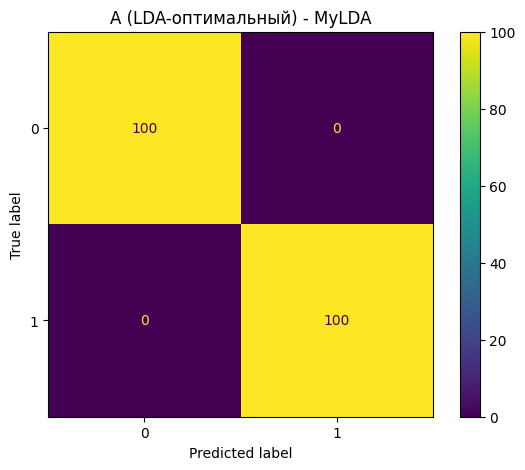

A (LDA-оптимальный) | MyNB: Acc=0.990, F1=0.990


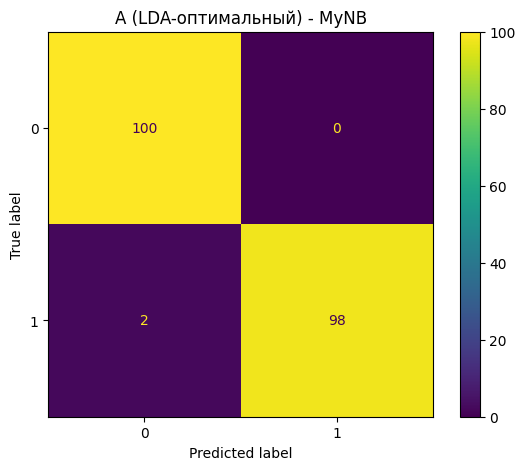

A (LDA-оптимальный) | LogReg: Acc=1.000, F1=1.000


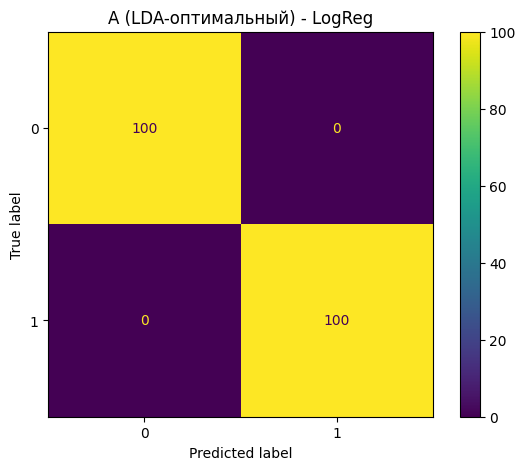

B (NB-оптимальный) | MyLDA: Acc=0.980, F1=0.980


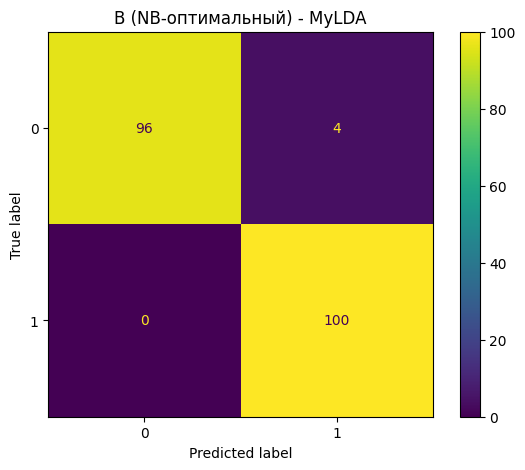

B (NB-оптимальный) | MyNB: Acc=0.920, F1=0.920


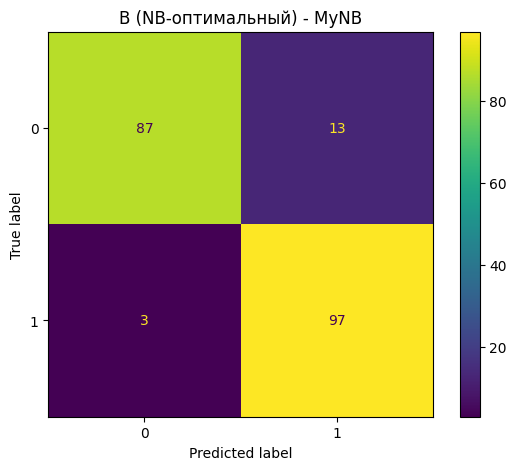

B (NB-оптимальный) | LogReg: Acc=0.975, F1=0.975


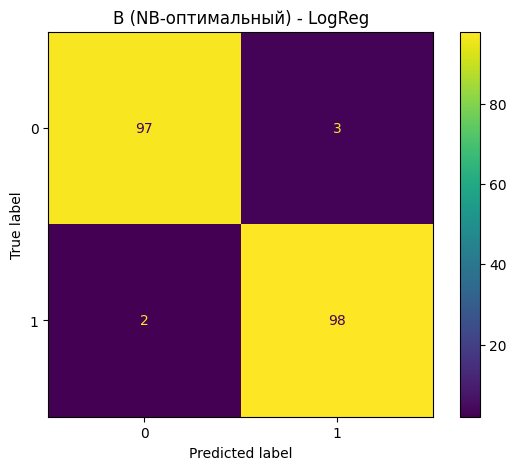

C (сложный) | MyLDA: Acc=0.770, F1=0.770


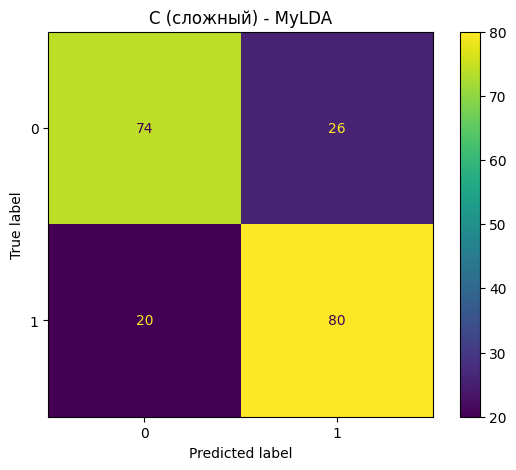

C (сложный) | MyNB: Acc=0.785, F1=0.784


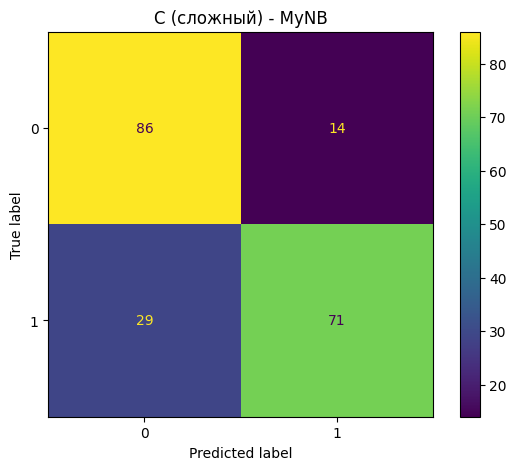

C (сложный) | LogReg: Acc=0.765, F1=0.765


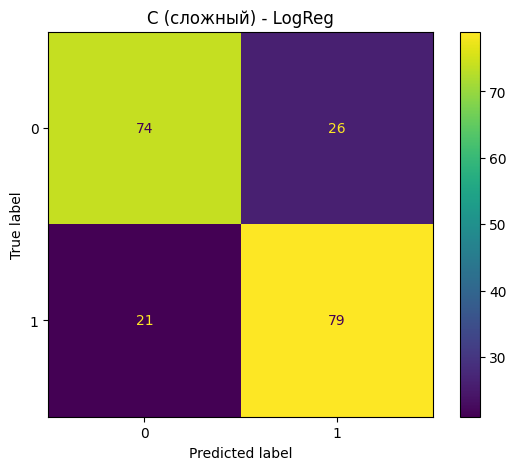

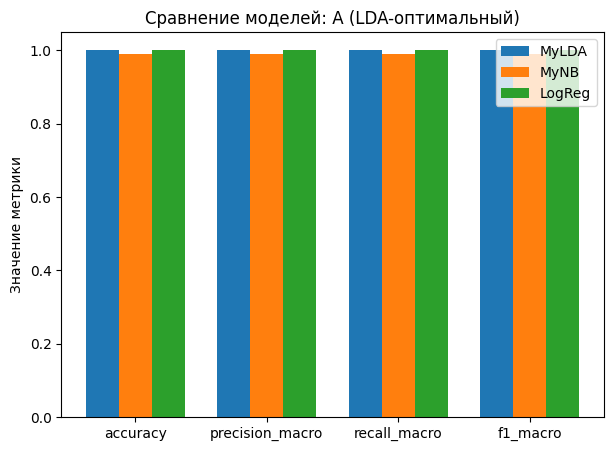

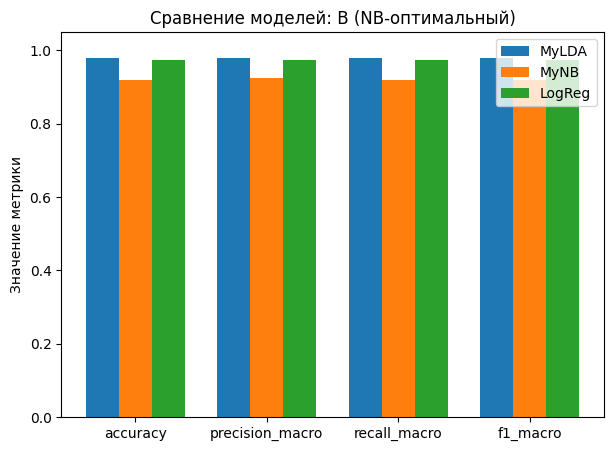

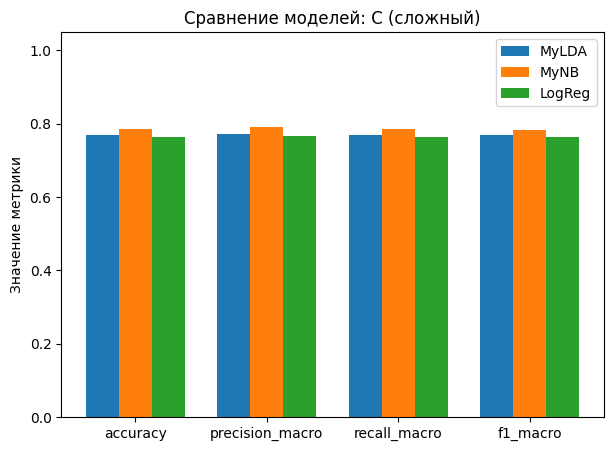

In [10]:
# Часть 6.1: генерация трех датасетов
datasets = {}

# A: LDA-оптимальный
X_A, y_A = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    flip_y=0.0,
    random_state=1
)
datasets['A (LDA-оптимальный)'] = (X_A, y_A)

# B: NB-оптимальный: признаки независимы
X_B, y_B = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    class_sep=1.0,
    flip_y=0.0,
    random_state=2
)
datasets['B (NB-оптимальный)'] = (X_B, y_B)

# C: сложный датасет
X_C, y_C = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    n_clusters_per_class=2,
    class_sep=0.8,
    flip_y=0.05,
    random_state=3
)
datasets['C (сложный)'] = (X_C, y_C)

# Часть 6.2: сравнение моделей
results = {}

for name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    models = {
        'MyLDA': MyLDA(),
        'MyNB': MyNB(),
        'LogReg': LogisticRegression(max_iter=1000)
    }

    results[name] = {}

    for mname, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results[name][mname] = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
            'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
            'cm': confusion_matrix(y_test, y_pred)
        }

        print(f"{name} | {mname}: "
              f"Acc={results[name][mname]['accuracy']:.3f}, "
              f"F1={results[name][mname]['f1_macro']:.3f}")

        ConfusionMatrixDisplay(results[name][mname]['cm']).plot()
        plt.title(f"{name} - {mname}")
        plt.show()

# Столбчатые диаграммы сравнения метрик
for name in results:
    metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
    x = np.arange(len(metrics))
    width = 0.25

    for i, mname in enumerate(results[name]):
        vals = [results[name][mname][m] for m in metrics]
        plt.bar(x + i * width, vals, width, label=mname)

    plt.xticks(x + width, metrics)
    plt.ylim(0, 1.05)
    plt.ylabel('Значение метрики')
    plt.title(f'Сравнение моделей: {name}')
    plt.legend()
    plt.show()